In [336]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score)
from sklearn.model_selection import cross_val_score

In [3]:
df = pd.read_csv(r"C:\Users\Neel Arora\OneDrive\Desktop\Advanced Machine Learning\Advanced Machine Learning\Ensemble Model\Boosting\Gradient Approach Boosting\Light GBM\Hotel Booking Special Request\hotel_bookings.csv.zip")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
drop_cols = [
    "reservation_status",
    "reservation_status_date",
    "is_canceled",
    "assigned_room_type",
    "agent",
    "company",
    "arrival_date_week_number",
    "arrival_date_day_of_month"
]
df.drop(drop_cols, axis=1, inplace=True)


Missing Values:
 country     488
children      4
dtype: int64


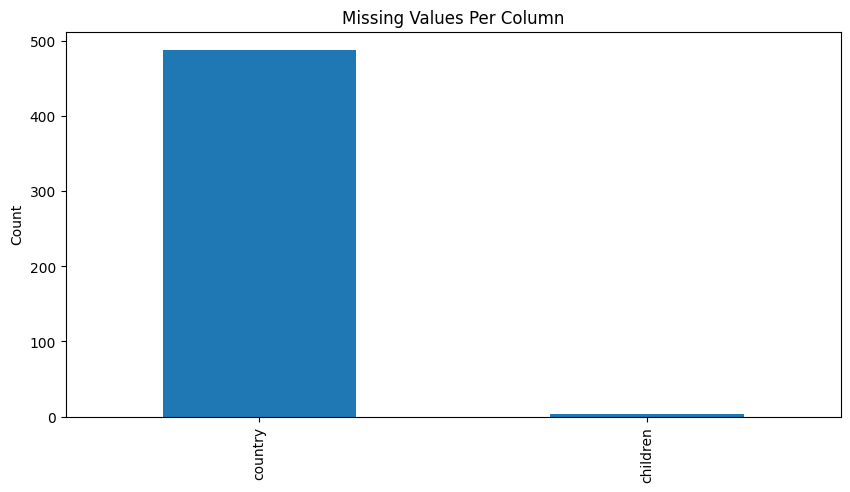

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
print("\nMissing Values:\n", missing[missing > 0])
plt.figure(figsize=(10,5))
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values Per Column")
plt.ylabel("Count")
plt.show()

In [7]:
df["children"] = df["children"].fillna(df["children"].median())
df["country"] = df["country"].fillna(df["country"].mode()[0])

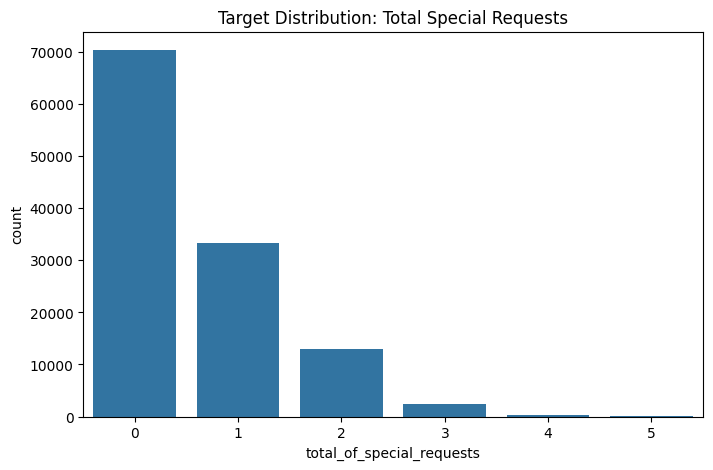

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["total_of_special_requests"])
plt.title("Target Distribution: Total Special Requests")
plt.show()

In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("Encoded Shape:", df_encoded.shape)

Encoded Shape: (119390, 232)


In [10]:
X = df_encoded.drop("total_of_special_requests", axis=1)
y = df_encoded["total_of_special_requests"]
print("\nTarget Classes:\n", y.value_counts())


Target Classes:
 total_of_special_requests
0    70318
1    33226
2    12969
3     2497
4      340
5       40
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (95512, 231)
Test Shape : (23878, 231)


In [12]:
model = LGBMClassifier(
    objective="multiclass",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=128,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

In [13]:
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 972
[LightGBM] [Info] Number of data points in the train set: 95512, number of used features: 123
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.05
,n_estimators,2000
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
print("\n✅ Accuracy:", accuracy)
print("✅ Weighted F1 Score:", f1)
print("\n📌 Classification Report:\n")
print(classification_report(y_test, y_pred))


✅ Accuracy: 0.7014825362258146
✅ Weighted F1 Score: 0.7045200670836764

📌 Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.79      0.82     14064
           1       0.55      0.65      0.60      6645
           2       0.42      0.43      0.42      2594
           3       0.48      0.22      0.30       499
           4       0.72      0.31      0.43        68
           5       0.50      0.12      0.20         8

    accuracy                           0.70     23878
   macro avg       0.59      0.42      0.46     23878
weighted avg       0.71      0.70      0.70     23878



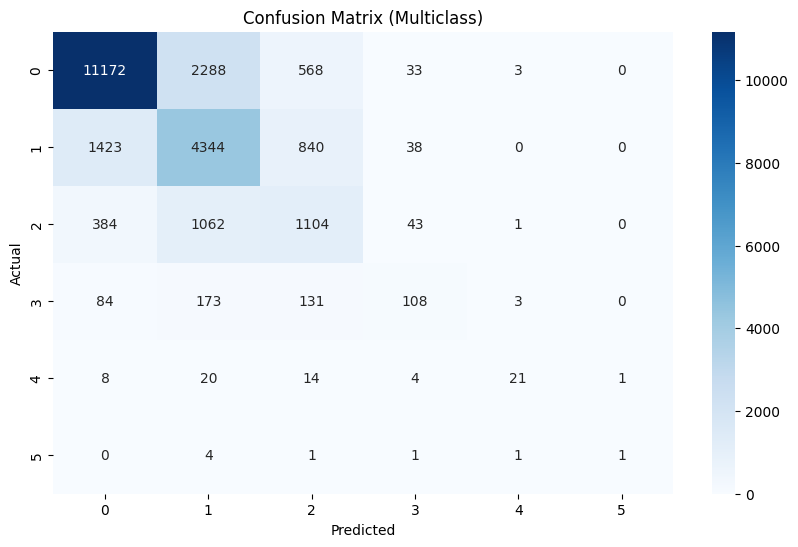

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Multiclass)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print("\nCross Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004143 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 971
[LightGBM] [Info] Number of data points in the train set: 95512, number of used features: 125
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

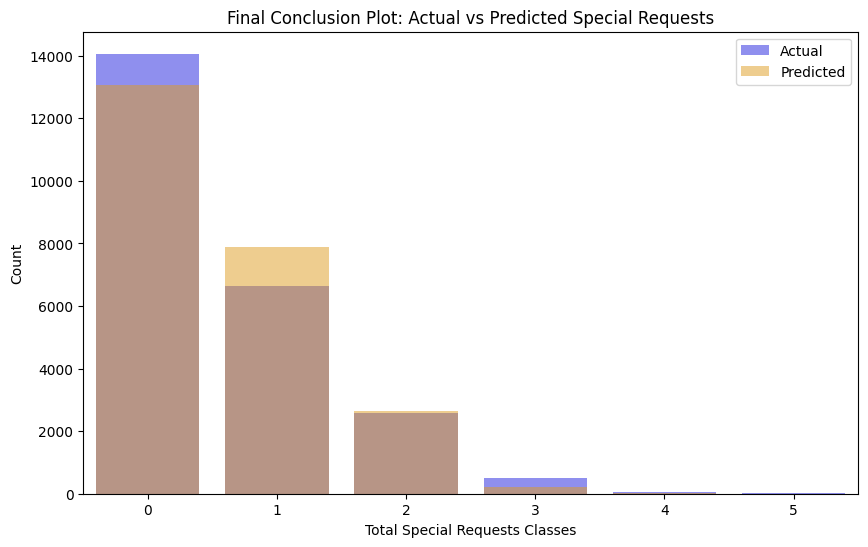

In [ ]:
plt.figure(figsize=(10,6))
# Plot Actual Distribution
sns.countplot(x=y_test, color="blue", alpha=0.5, label="Actual")
# Plot Predicted Distribution
sns.countplot(x=y_pred, color="orange", alpha=0.5, label="Predicted")
plt.title("Final Conclusion Plot: Actual vs Predicted Special Requests")
plt.xlabel("Total Special Requests Classes")
plt.ylabel("Count")
plt.legend()
plt.show()